<a href="https://colab.research.google.com/github/Ratan573/BUG--Attraction-in-Eda/blob/main/Bug_attrection_in_Eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv('/content/bug-attraction.csv')

display(df.head())

,Light Type,Model Lamp,Location,Site,Standardized Moon,Standardized Mean Temp,Standardized Mean Humidity,Standardized Max Wind,% Moon Visible,Start Tem,...,Arachnid,Thysanura,Isoptera,Lepidoptera,Neuroptera,Larave,Orthoptera,Unident,Total,Other Orders
0,A,3500 Custom,BG,B3,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,1.0
1,B,2700 Custom,BG,B4,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,2.0
2,C,2700 Custom,BG,B2,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,11.0,3.0
3,LED,LED,BG,B5,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,5.0
4,CFL,CFL,BG,B1,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,4.0


In [ ]:
null_counts = df.isnull().sum()
print("Null values in each column:")
display(null_counts[null_counts > 0])

Null values in each column:


,0
Diptera,1
Hymenoptera,1
Hemiptera,1
Psocoptera,1
Coleoptera,1
Collembola,2
Arachnid,1
Thysanura,1
Isoptera,1
Lepidoptera,1


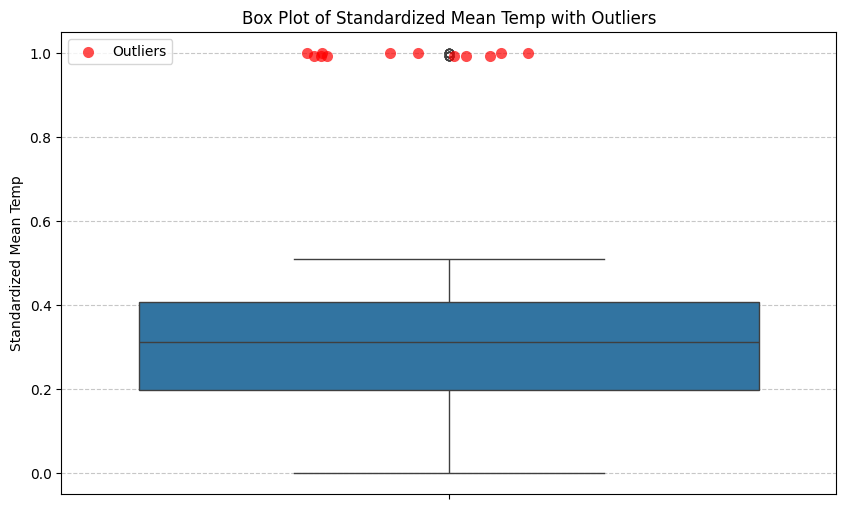

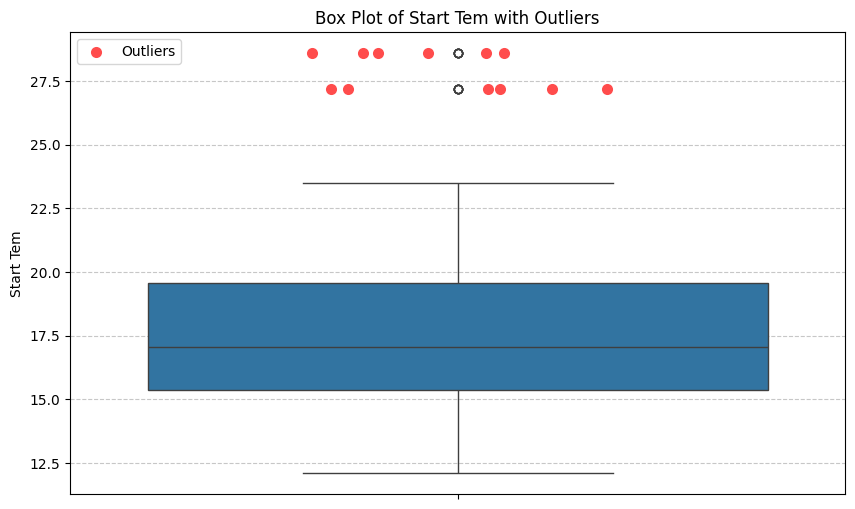

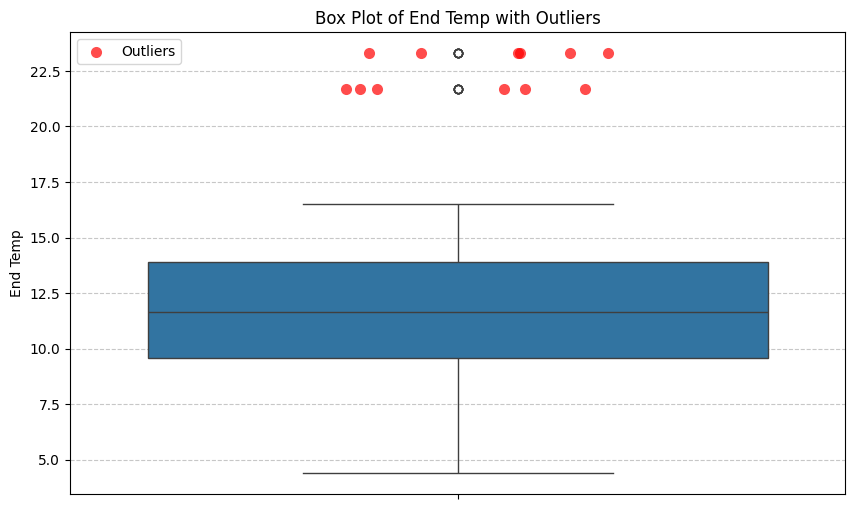

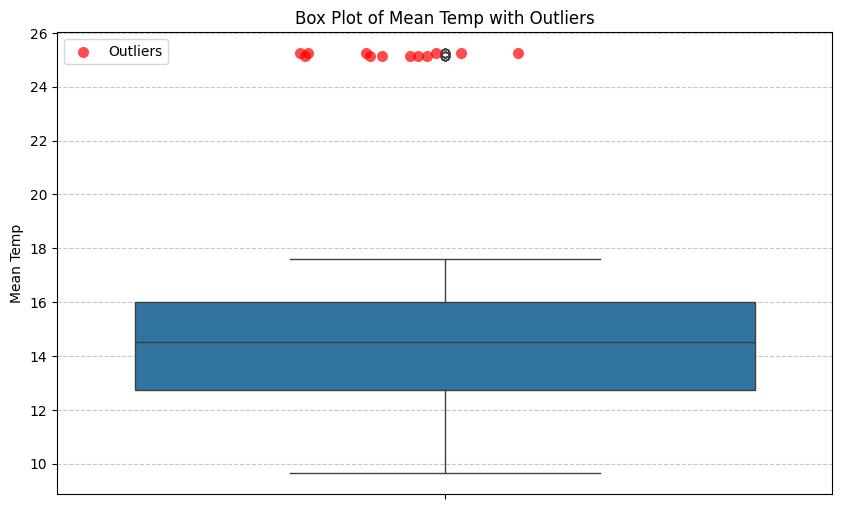

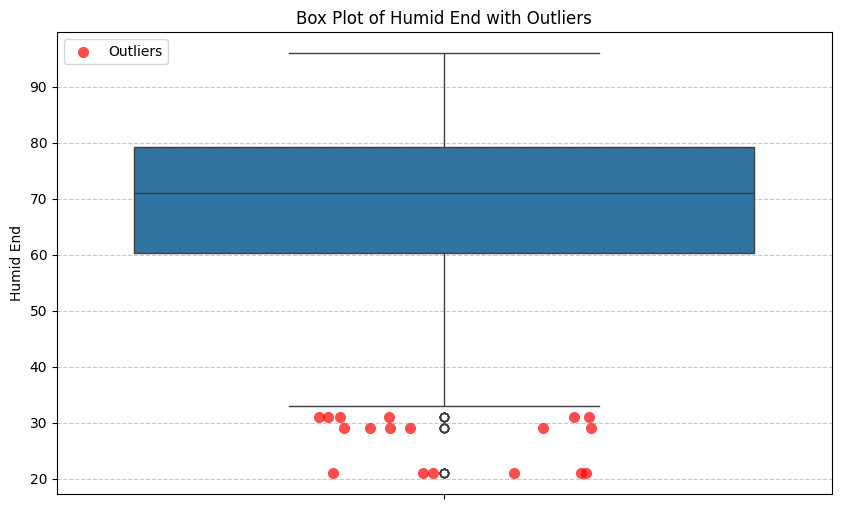

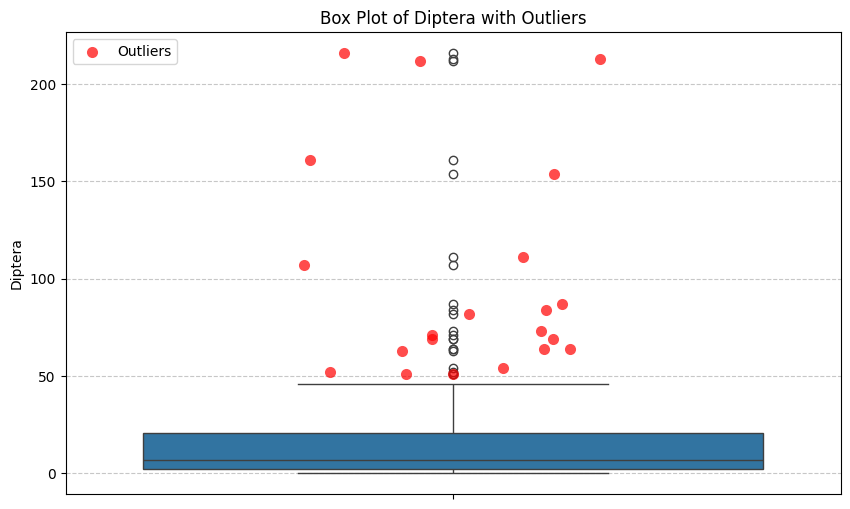

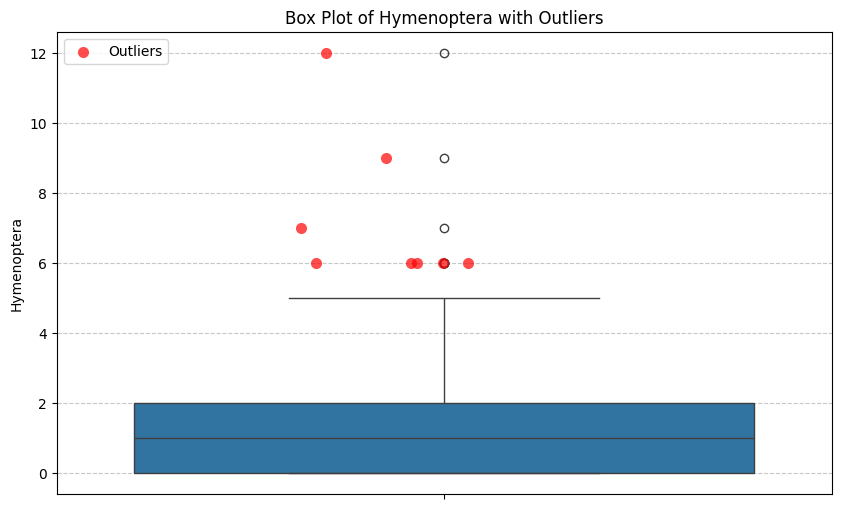

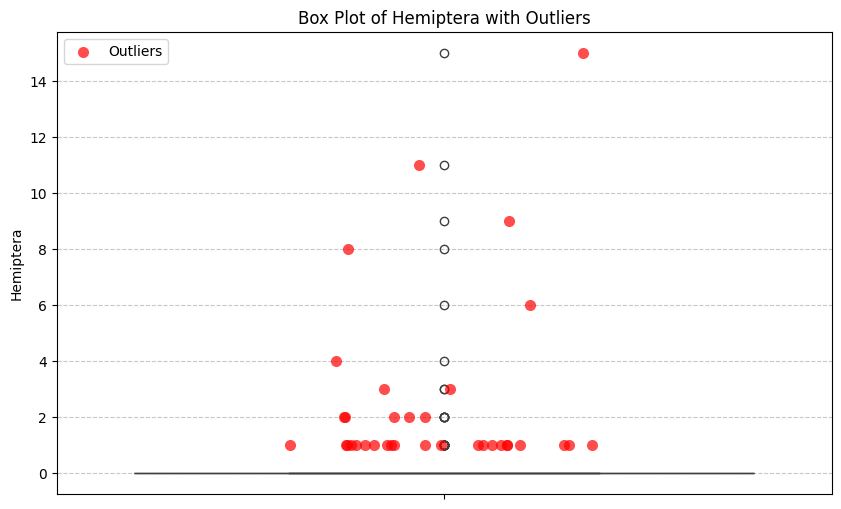

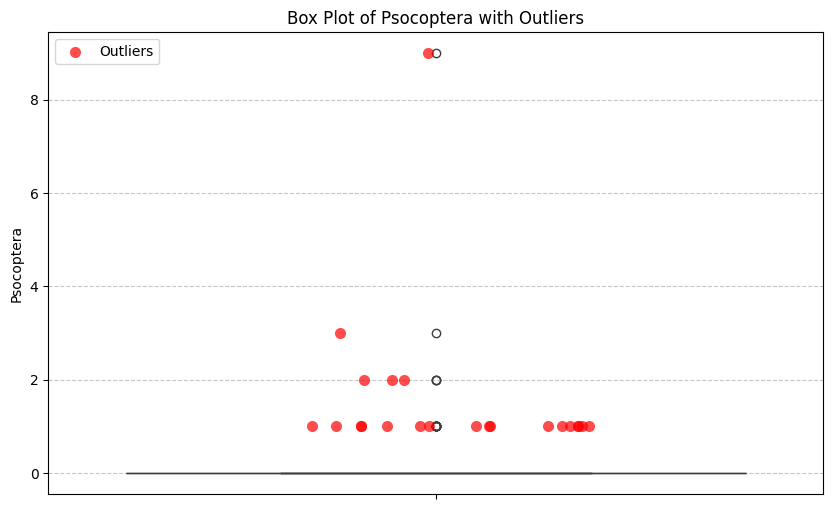

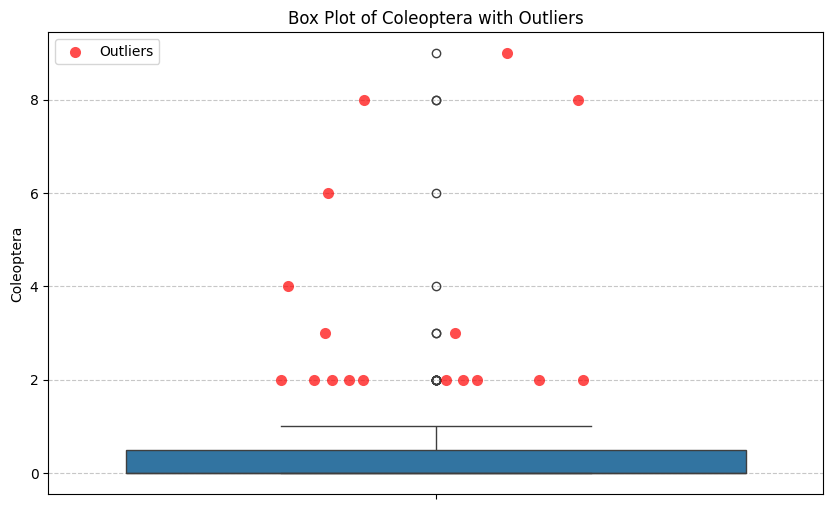

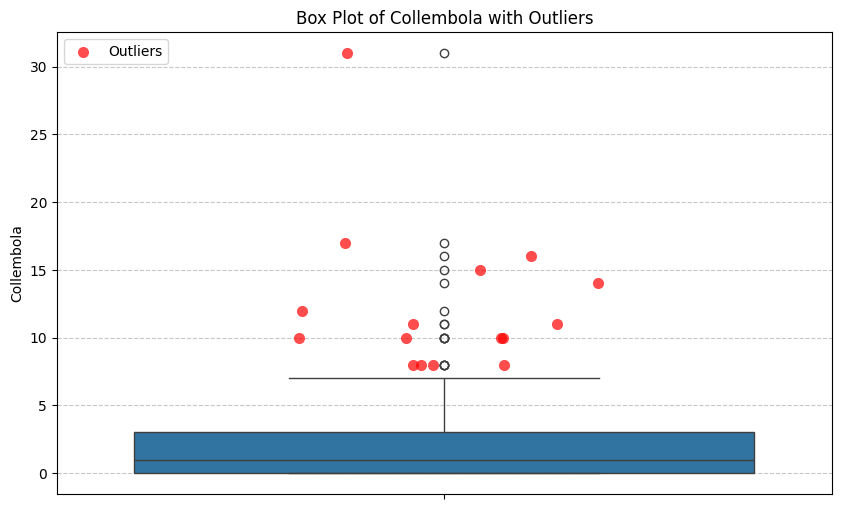

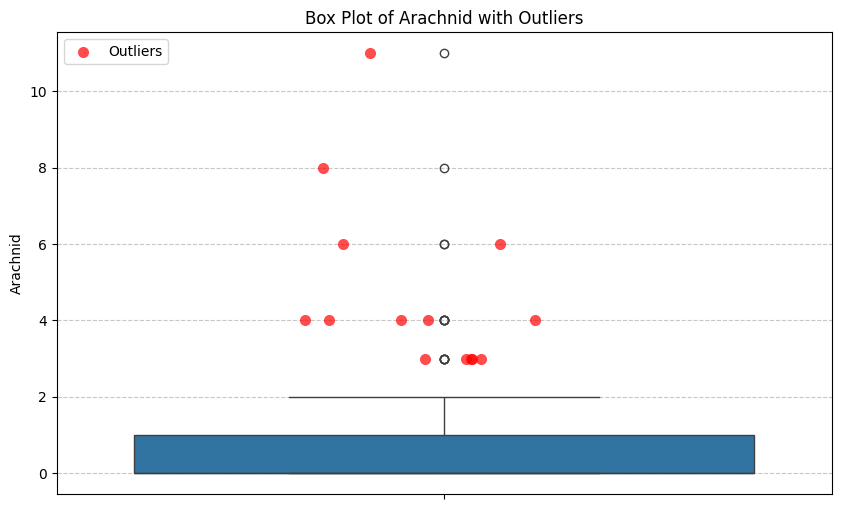

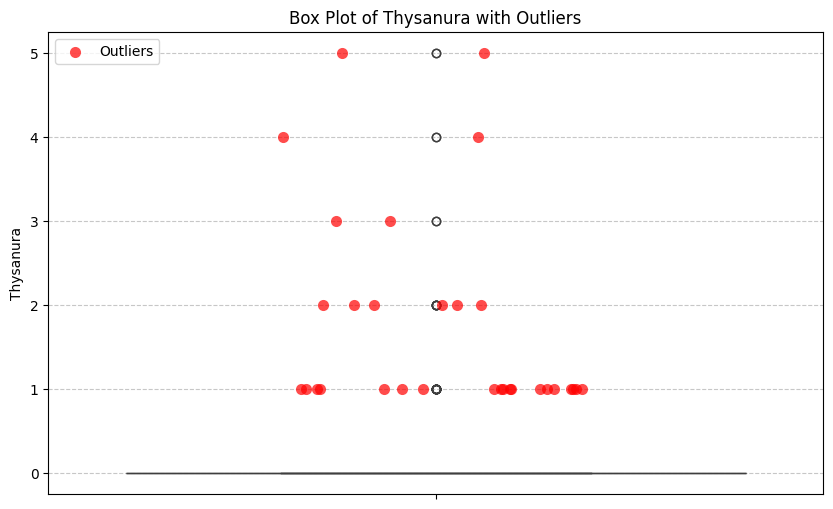

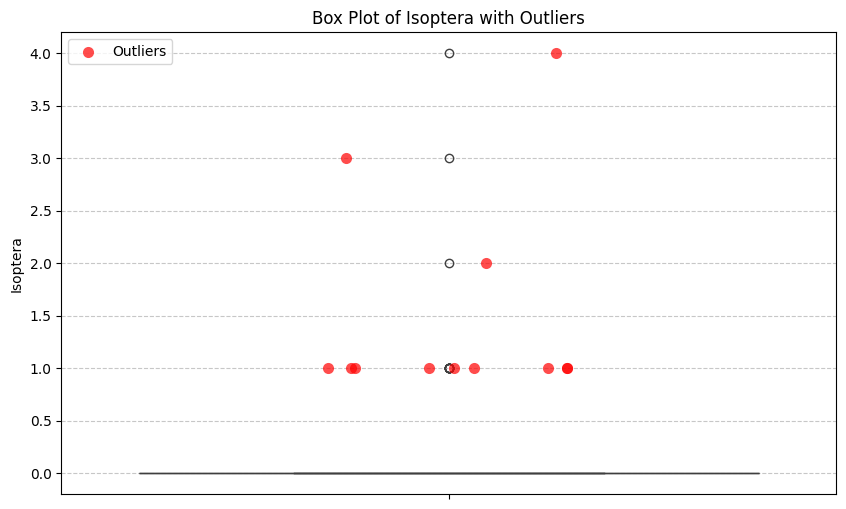

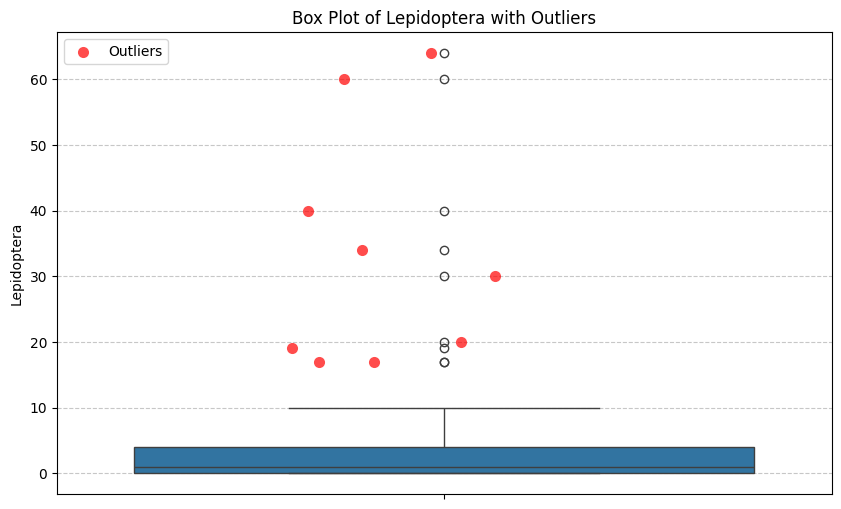

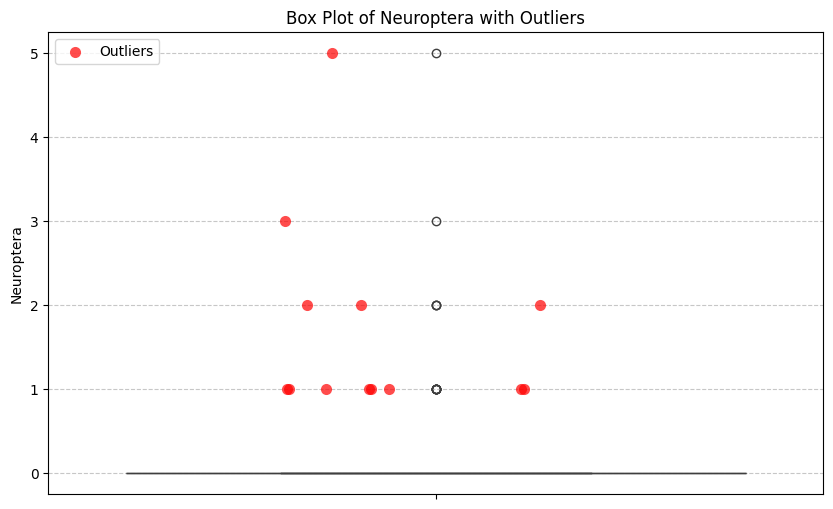

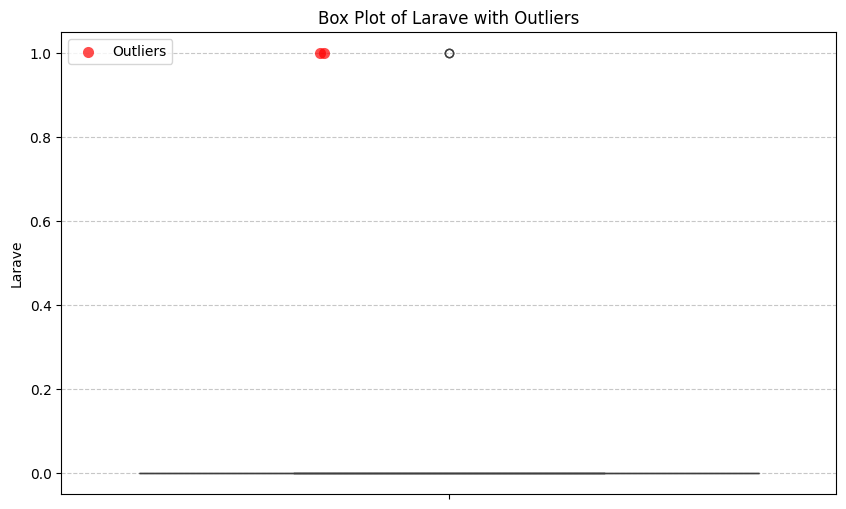

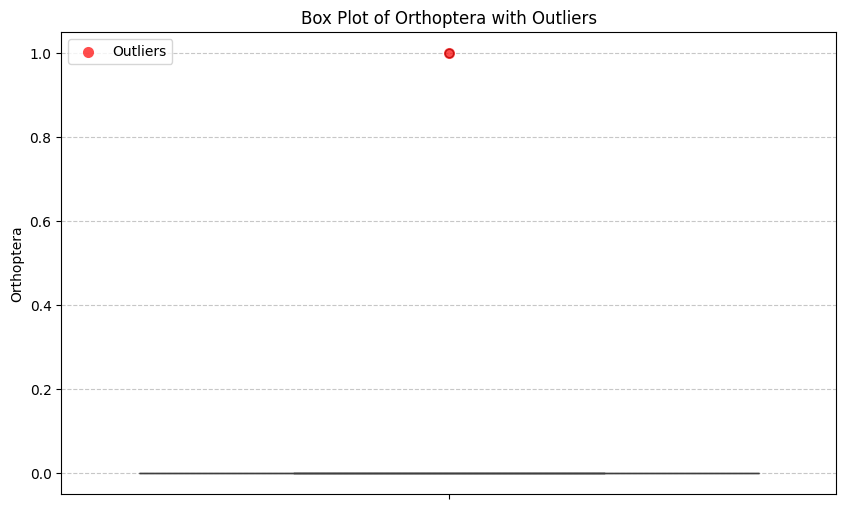

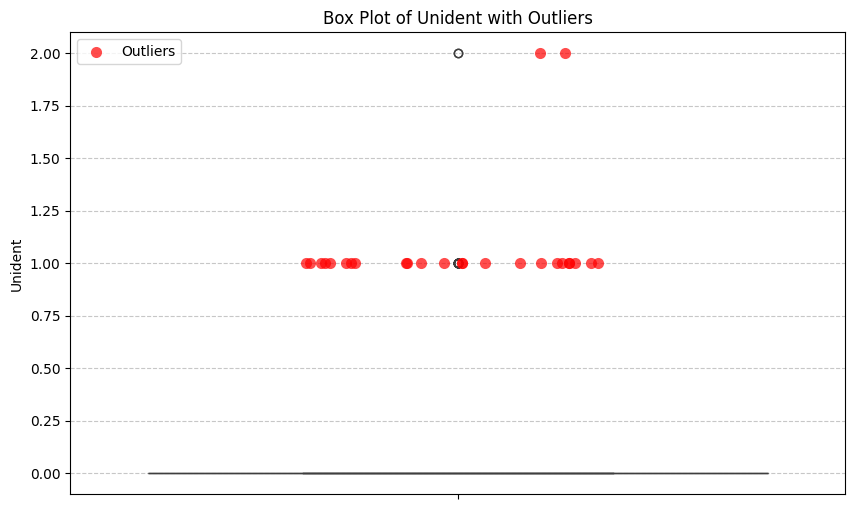

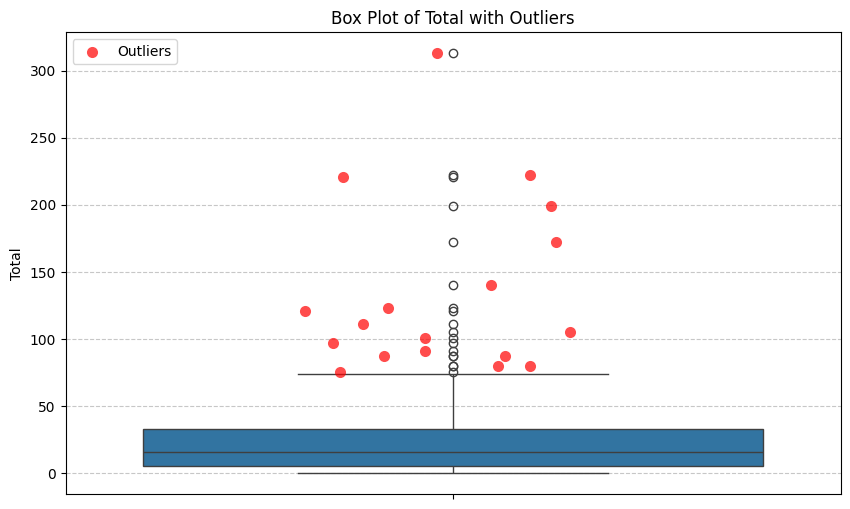

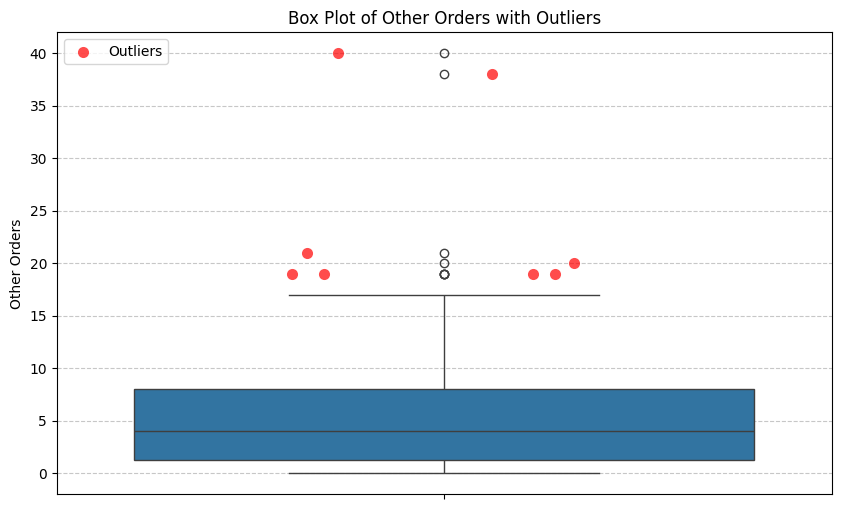

In [ ]:
for col, data in outliers_data.items():
    if data['Outliers Count'] > 0:
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col} with Outliers')
        plt.ylabel(col)

        # Optional: Add points for individual outliers if desired
        Q1 = data['Q1']
        Q3 = data['Q3']
        IQR = data['IQR']
        lower_bound = data['Lower Bound']
        upper_bound = data['Upper Bound']

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        if not outliers.empty:
            sns.stripplot(y=outliers, color='red', jitter=0.2, size=8, marker='o', alpha=0.7, label='Outliers')
            plt.legend(loc='upper left')

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

In [ ]:
df_cleaned = df.copy()

print("Applying outlier capping...")

for col, data in outliers_data.items():
    if data['Outliers Count'] > 0:
        lower_bound = data['Lower Bound']
        upper_bound = data['Upper Bound']

        df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])

        df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
        print(f"  - Capped outliers in column: {col}")

print("\nOutlier capping complete. Displaying descriptive statistics for 'df_cleaned' (first 5 rows and info).")

display(df_cleaned.head())
df_cleaned.info()

Applying outlier capping...
  - Capped outliers in column: Standardized Mean Temp
  - Capped outliers in column: Start Tem
  - Capped outliers in column: End Temp
  - Capped outliers in column: Mean Temp
  - Capped outliers in column: Humid End
  - Capped outliers in column: Diptera
  - Capped outliers in column: Hymenoptera
  - Capped outliers in column: Hemiptera
  - Capped outliers in column: Psocoptera
  - Capped outliers in column: Coleoptera
  - Capped outliers in column: Collembola
  - Capped outliers in column: Arachnid
  - Capped outliers in column: Thysanura
  - Capped outliers in column: Isoptera
  - Capped outliers in column: Lepidoptera
  - Capped outliers in column: Neuroptera
  - Capped outliers in column: Larave
  - Capped outliers in column: Orthoptera
  - Capped outliers in column: Unident
  - Capped outliers in column: Total
  - Capped outliers in column: Other Orders

Outlier capping complete. Displaying descriptive statistics for 'df_cleaned' (first 5 rows and info

,Light Type,Model Lamp,Location,Site,Standardized Moon,Standardized Mean Temp,Standardized Mean Humidity,Standardized Max Wind,% Moon Visible,Start Tem,...,Arachnid,Thysanura,Isoptera,Lepidoptera,Neuroptera,Larave,Orthoptera,Unident,Total,Other Orders
0,A,3500 Custom,BG,B3,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,1.0
1,B,2700 Custom,BG,B4,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,2.0
2,C,2700 Custom,BG,B2,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,3.0
3,LED,LED,BG,B5,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,5.0
4,CFL,CFL,BG,B1,0.92436,0.448718,0.628571,0.0,93.0,18.3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,4.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Light Type                  192 non-null    object 
 1   Model Lamp                  192 non-null    object 
 2   Location                    192 non-null    object 
 3   Site                        192 non-null    object 
 4   Standardized Moon           192 non-null    float64
 5   Standardized Mean Temp      192 non-null    float64
 6   Standardized Mean Humidity  192 non-null    float64
 7   Standardized Max Wind       192 non-null    float64
 8   % Moon Visible              192 non-null    float64
 9   Start Tem                   192 non-null    float64
 10  End Temp                    192 non-null    float64
 11  Mean Temp                   192 non-null    float64
 12  Humid Start                 192 non-null    int64  
 13  Humid End                   192 non


Number of outliers in 'Other Orders' after capping: 0


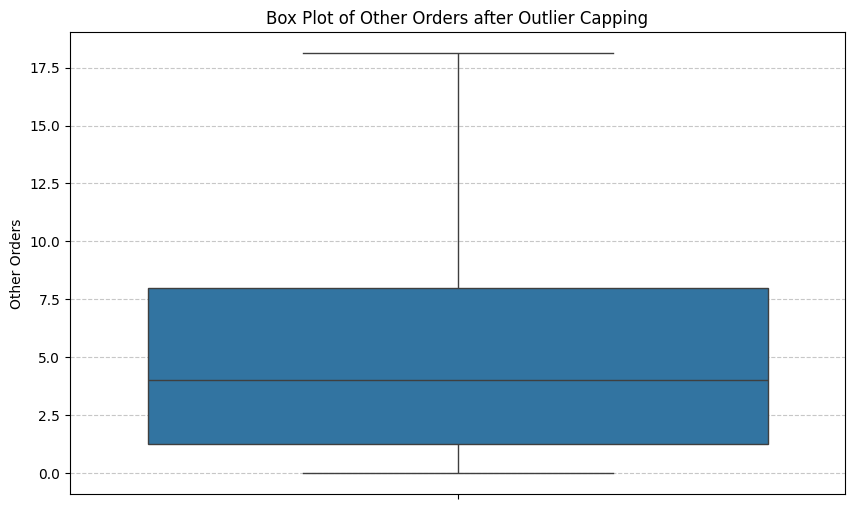

In [ ]:
# Re-check outliers for a specific column after capping (e.g., 'Other Orders')
col_to_check = 'Other Orders'
if col_to_check in outliers_data and outliers_data[col_to_check]['Outliers Count'] > 0:
    Q1 = outliers_data[col_to_check]['Q1']
    Q3 = outliers_data[col_to_check]['Q3']
    IQR = outliers_data[col_to_check]['IQR']
    lower_bound = outliers_data[col_to_check]['Lower Bound']
    upper_bound = outliers_data[col_to_check]['Upper Bound']

    outliers_after_capping = df_cleaned[(df_cleaned[col_to_check] < lower_bound) | (df_cleaned[col_to_check] > upper_bound)]

    print(f"\nNumber of outliers in '{col_to_check}' after capping: {len(outliers_after_capping)}")

    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df_cleaned[col_to_check])
    plt.title(f'Box Plot of {col_to_check} after Outlier Capping')
    plt.ylabel(col_to_check)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print(f"Column '{col_to_check}' did not have outliers or was not processed.")

In [ ]:
import plotly.express as px


# create an interactive by using  scatter plot.
df = px.scatter(df, x="Standardized Mean Temp", y="Total",
                 title="Interactive Scatter Plot of Mean Temp vs. Total Orders",
                 hover_data=['Light Type', 'Model Lamp', 'Site'])

df.show()